In [6]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [8]:
# loading processed data

import sys
import os

sys.path.append(os.path.abspath(".."))


from src.data_preprocessing import load_data, clean_data
from src.feature_eng import encode_features

df = load_data("../data/processed/telco_clean.csv")
df = clean_data(df)
df = encode_features(df)

In [9]:
print(df.columns)

Index(['Unnamed:_0', 'Senior_Citizen', 'Partner', 'Dependents',
       'Tenure_Months', 'Phone_Service', 'Paperless_Billing',
       'Monthly_Charges', 'Total_Charges', 'Churn_Label', 'Churn_Value',
       'Churn_Score', 'CLTV', 'Revenue_Loss', 'Churn_Prob', 'Expected_Loss',
       'Avg_Charges', 'Gender_Male', 'Multiple_Lines_No phone service',
       'Multiple_Lines_Yes', 'Internet_Service_Fiber optic',
       'Internet_Service_No', 'Online_Security_No internet service',
       'Online_Security_Yes', 'Online_Backup_No internet service',
       'Online_Backup_Yes', 'Device_Protection_No internet service',
       'Device_Protection_Yes', 'Tech_Support_No internet service',
       'Tech_Support_Yes', 'Streaming_TV_No internet service',
       'Streaming_TV_Yes', 'Streaming_Movies_No internet service',
       'Streaming_Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Payment_Method_Credit card (automatic)',
       'Payment_Method_Electronic check', 'Payment_Method_Mailed c

In [10]:
# defining feature and target
X = df.drop(['Churn_Value', 'Churn_Label'], axis=1)
y = df['Churn_Value']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# defining models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [13]:
# training and evaluation
results = []

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results.append([name, acc, prec, rec, f1, roc])


C:\Users\Gayatri\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:30:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [14]:
# showing the results
results_df = pd.DataFrame(results, columns=[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'
])

results_df.sort_values(by='ROC-AUC', ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,XGBoost,1.0,1.0,1.0,1.0,1.0


In [15]:
#  1. Predict churn probability
df['churn_prob'] = model.predict_proba(X)[:, 1]

In [16]:
#  2. Calculate Expected Revenue Loss
df['revenue_loss'] = df['Monthly_Charges'] * df['churn_prob']

In [17]:
#  3. Total Revenue at Risk
total_risk = df['revenue_loss'].sum()
print("Total Revenue at Risk:", total_risk)

Total Revenue at Risk: 139117.36440734245


In [19]:
# top risky customers
top_risky = df.sort_values(by='revenue_loss', ascending=False)

top_risky[[
    'Tenure_Months',
    'Monthly_Charges',
    'Contract_One year',
    'Contract_Two year',
    'churn_prob',
    'revenue_loss'
]].head(10)

,Tenure_Months,Monthly_Charges,Contract_One year,Contract_Two year,churn_prob,revenue_loss
1347,67,118.35,True,False,0.99944,118.283782
1206,72,117.80,True,False,0.99944,117.734090
1275,48,117.45,False,False,0.99944,117.384286
1661,67,116.20,False,True,0.99944,116.134985
1729,70,115.65,True,False,0.99944,115.585293
339,70,115.55,True,False,0.99944,115.485349
283,41,114.50,False,False,0.99944,114.435936
1596,70,114.20,False,True,0.99944,114.136104
442,41,113.60,False,False,0.99944,113.536440
460,41,113.20,False,False,0.99944,113.136664


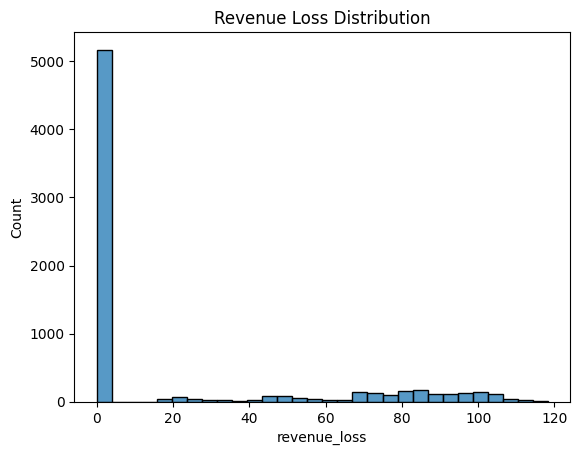

In [20]:
# visualizing risk distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['revenue_loss'], bins=30)
plt.title("Revenue Loss Distribution")
plt.show()


In [22]:
# Key Insights:
#1)High monthly charge customers with high churn probability contribute most to revenue risk
#2)Short tenure + month-to-month contracts dominate high-risk group


# Business Actions:
#1)Target top risky customers with retention offers
#2)Provide discounts for long-term contracts
#3)Focus on high-value customers first